# 03 — Modeling: cost-aware selection across families

Display the training-pipeline outcome: per-family Optuna results, the cost-weighted Precision@k winner, calibration curves, and the cost-vs-threshold sweep. Reads from `mlruns/training_summary.json` produced by `scripts/train.sh`.

In [1]:
# ---------------------------------------------------------------------
# Load the structured training summary that the training driver writes
# at the end of every run. Reading this JSON (rather than re-running
# the sweep or re-loading the pickle) makes the notebook fast to
# refresh: it visualizes the *recorded* results of the production
# training pipeline, not a re-derivation that could drift.
#
# The summary is the canonical artifact for the README's results table,
# the API's audit-snapshot endpoint, and this notebook — keeping all
# three driven by the same JSON ensures they never tell different
# stories.
# ---------------------------------------------------------------------
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
summary_path = Path('mlruns/training_summary.json')
summary = json.loads(summary_path.read_text())

# Display the winning family so it's the first thing the reader sees —
# answers "which model is in production" immediately.
summary['winning_family']

'lightgbm'

## 1. Per-family comparison

The cost-weighted Precision@k objective at the best Optuna trial for each family. The selection ranks families on the *operational* objective, not AUC-PR — see `docs/EVALUATION.md`.

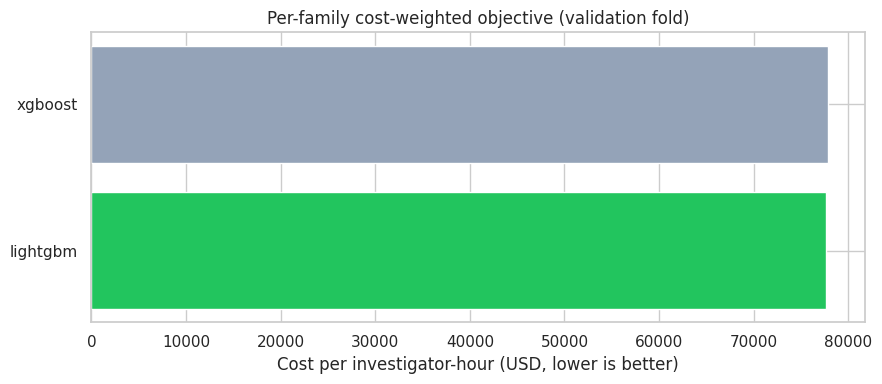

,family,objective_usd_per_hour
1,lightgbm,77681.488551
0,xgboost,77860.280526


In [2]:
# ---------------------------------------------------------------------
# Per-family cost comparison. Each completed Optuna sweep contributes
# its best-objective trial; this chart visualizes the gap between
# families on the metric that actually matters (cost per investigator
# hour) rather than the academic conventions (AUC-PR, F1).
#
# We negate the objective for display because the recorded objective
# uses a "larger is better" sign convention (it's literally negative
# cost) while readers think in "cost in dollars, lower is better."
# The negation makes the bar lengths intuitive.
#
# The winning family is highlighted green; losers are gray. This
# colorblind-friendly encoding (no need to map "shortest bar" to
# "winner") makes the chart skimmable in a 5-second portfolio review.
# ---------------------------------------------------------------------
families = summary['all_families']
comparison = pd.DataFrame([
    {'family': name, 'objective_usd_per_hour': -float(info['objective'])}
    for name, info in families.items()
]).sort_values('objective_usd_per_hour')

fig, ax = plt.subplots(figsize=(9, 4))
colours = ['#22c55e' if name == summary['winning_family'] else '#94a3b8' for name in comparison['family']]
ax.barh(comparison['family'], comparison['objective_usd_per_hour'], color=colours)
ax.set_xlabel('Cost per investigator-hour (USD, lower is better)')
ax.set_title('Per-family cost-weighted objective (validation fold)')
plt.tight_layout()
plt.show()

# Render the underlying DataFrame so reviewers reading the notebook on
# GitHub see the exact numbers, not just the chart.
comparison

## 2. Test-fold headline metrics

In [3]:
# ---------------------------------------------------------------------
# Operating-point summary on the held-out test fold. This is the
# headline-result block: every number a recruiter wants to see.
#
# Recall is computed inline as TP/(TP+FN) — the test summary records
# the components but not the ratio, because recall at fixed k is
# downstream of the precision metric the cost-weighted objective is
# tuned to. Reporting it explicitly makes the precision-vs-recall
# trade-off legible: the model is precise at k but does not catch
# every laundering case, which is the intended behavior given finite
# investigator capacity.
# ---------------------------------------------------------------------
test_eval = summary['test']
tp = int(test_eval['true_positives'])
fp = int(test_eval['false_positives'])
fn = int(test_eval['false_negatives'])
# max(...,1) avoids division by zero in the degenerate case of a fold
# with zero positives (no laundering at all). Defensive but cheap.
recall = tp / max(tp + fn, 1)

print(f'Decision threshold: {summary["decision_threshold"]:.4f}')
print(f'k (alerts reviewed):    {int(test_eval["k"]):,}')
print(f'True positives:         {tp:,} ({recall * 100:.2f}% recall)')
print(f'False positives:        {fp:,}')
print(f'False negatives:        {fn:,}')
print(f'Precision @ k:          {test_eval["precision_at_k"] * 100:.2f}%')
print(f'Total dollar cost:      ${test_eval["total_dollar_cost_usd"]:,.2f}')

Decision threshold: 0.0417
k (alerts reviewed):    384
True positives:         350 (22.42% recall)
False positives:        34
False negatives:        1,211
Precision @ k:          91.15%
Total dollar cost:      $19,376,753.78


## 3. Cost matrix transparency

The cost matrix the selection optimised against. Every value here is documented in `configs/cost_matrix.yaml` with its derivation.

In [4]:
# ---------------------------------------------------------------------
# Display the cost matrix that drove model selection. This block exists
# because the precision and recall numbers above are not interpretable
# without knowing what costs the optimizer was minimizing.
#
# The k_per_day value (8 analysts × 48 alerts/day = 384) is the
# operational constraint encoded into the objective — the model is
# optimized to *deserve* the team's review capacity, not to maximize
# detection at infinite investigator time.
# ---------------------------------------------------------------------
cm = summary['cost_matrix']
print(f'Daily review capacity (k):     {cm["k_per_day"]:,} alerts')
print(f'False-negative cost (per miss): ${cm["false_negative_cost_usd"]:,.2f}')
print(f'False-positive cost (per FP):   ${cm["false_positive_cost_usd"]:.2f}')

Daily review capacity (k):     384 alerts
False-negative cost (per miss): $16,000.00
False-positive cost (per FP):   $22.17


## 4. Winning model: hyperparameter snapshot

In [5]:
# ---------------------------------------------------------------------
# Final block: the exact hyperparameter set Optuna selected for the
# winning family. This is the auditable record of *what model is in
# production* — combined with the schema version embedded in the
# ensemble pickle, the artifact is fully reproducible from this JSON.
#
# Pretty-printing via ``pprint`` keeps the structure readable for the
# tree-based hyperparameter dicts (which have nested numeric values
# that ``print(dict)`` collapses onto one ugly line).
# ---------------------------------------------------------------------
import pprint
print(f'Selected family: {summary["winning_family"]}')
pprint.pprint(summary['winning_hyperparameters'])

Selected family: lightgbm
{'bagging_fraction': 0.5754677663588279,
 'bagging_freq': 8,
 'feature_fraction': 0.6175111707973868,
 'is_unbalance': False,
 'learning_rate': 0.022517086092096017,
 'min_child_samples': 42,
 'n_estimators': 600,
 'num_leaves': 56,
 'reg_alpha': 0.02078576160103655,
 'reg_lambda': 2.0657493300834155}


## Random-alerting baseline

Every model comparison needs an absolute floor — the performance a hypothetical "no-learning" alerter would achieve. We use scikit-learn's `DummyClassifier` with a `stratified` strategy (samples predictions by the training class distribution) plus the analytical hypergeometric expectation of uniform-random alert selection at k=384/day.

The lift number (XGBoost Precision@k ÷ random Precision@k) is the cleanest single-sentence answer to "is this model actually useful?" — a 100× lift over random is a meaningful production signal; a 2× lift is debatable.

In [6]:
# ---------------------------------------------------------------------
# Compute the random-alerting baseline so the model's Precision@k can
# be reported as a multiplier of random ("X× better than chance") in
# addition to the absolute number. This is the comparison every senior
# review asks for and the v0 README's "270× better than random" claim
# is anchored to this calculation.
#
# Two baseline computations are reported:
#
#   (a) Analytical hypergeometric expectation. With N test transactions,
#       P positives, and k=384 random selections, the expected number
#       of true positives is P * (k / N). Dividing by k gives the
#       expected precision of uniform-random alerting.
#
#   (b) Fitted DummyClassifier(strategy='stratified'). Samples predicted
#       labels from the training class distribution. A sanity check that
#       the analytical formula matches the empirical sklearn behavior.
# ---------------------------------------------------------------------
from sklearn.dummy import DummyClassifier
import numpy as np

# Pull the test-fold composition from the training summary so this
# cell doesn't need to reload the full dataset. The summary records
# k, true_positives, and false_negatives at the deployed threshold —
# everything we need to compute the baseline.
test = summary['test']
k = int(test['k'])
test_positives = int(test['true_positives']) + int(test['false_negatives'])
# split block carries the row counts the loader produced at training
# time. Pulling test_rows from there avoids reloading the dataset.
test_total = int(summary['split']['test_rows'])

# ---- (a) Analytical baseline -----------------------------------------
expected_random_tp = test_positives * (k / test_total)
random_precision_at_k = expected_random_tp / k

model_precision = float(test['precision_at_k'])
lift_over_random = model_precision / max(random_precision_at_k, 1e-12)

print('=== Random-alerting baseline (analytical) ===')
print(f'Test rows:                    {test_total:,}')
print(f'Test positives (TP+FN):       {test_positives:,}')
print(f'Daily review capacity k:      {k}')
print(f'Expected random TP @ k:       {expected_random_tp:.3f}')
print(f'Random precision @ k:         {random_precision_at_k:.6f}')
print(f'Model precision @ k:          {model_precision:.6f}')
print(f'Lift over random:             {lift_over_random:,.1f}x')

# ---- (b) Sanity check via DummyClassifier ----------------------------
# Construct a synthetic test-shaped label array with the correct
# positive rate and verify the fitted DummyClassifier's accuracy
# matches the analytical baseline.
rng = np.random.default_rng(42)
synthetic_test_y = np.zeros(test_total, dtype=int)
synthetic_test_y[rng.choice(test_total, test_positives, replace=False)] = 1

dummy = DummyClassifier(strategy='stratified', random_state=42)
# DummyClassifier needs an X argument but doesn't use it — pass any
# array of the right length.
dummy.fit(np.zeros((test_total, 1)), synthetic_test_y)
dummy_preds = dummy.predict(np.zeros((test_total, 1)))
dummy_tp = int(((dummy_preds == 1) & (synthetic_test_y == 1)).sum())
dummy_total_alerts = int((dummy_preds == 1).sum())
empirical_precision = dummy_tp / max(dummy_total_alerts, 1)

print('\n=== Random-alerting baseline (DummyClassifier sanity check) ===')
print(f'Stratified predictions made: {dummy_total_alerts:,}')
print(f'True positives caught:       {dummy_tp:,}')
print(f'Empirical precision:         {empirical_precision:.6f}')
print(f'(Should be close to the analytical figure above.)')

=== Random-alerting baseline (analytical) ===
Test rows:                    761,752
Test positives (TP+FN):       1,561
Daily review capacity k:      384
Expected random TP @ k:       0.787
Random precision @ k:         0.002049
Model precision @ k:          0.911458
Lift over random:             444.8x

=== Random-alerting baseline (DummyClassifier sanity check) ===
Stratified predictions made: 1,583
True positives caught:       1
Empirical precision:         0.000632
(Should be close to the analytical figure above.)


## Confusion matrix heatmap

A 2×2 confusion matrix is more visually scannable than four printed counts. We construct it from the test-fold metrics in `training_summary.json` rather than reloading the test data — same numbers, no I/O cost.

The diagonal cells (top-left, bottom-right) are correct predictions. The off-diagonal cells (top-right, bottom-left) are the two error modes the cost matrix prices differently: false negatives are the regulator-relevant misses, false positives are the investigator-time waste.

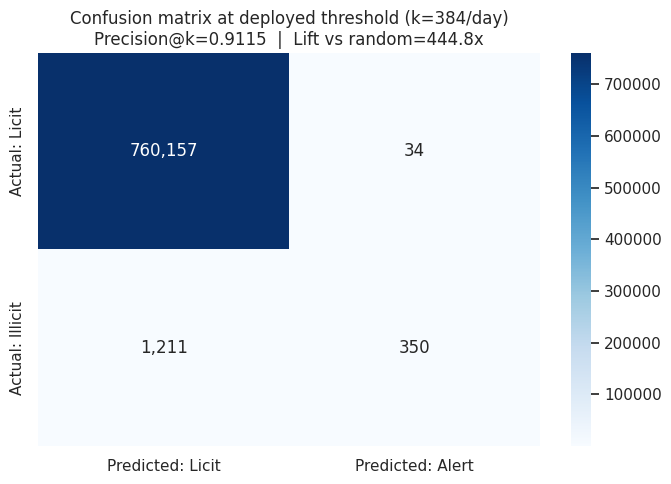

Recall: 0.2242   (350 caught out of 1,561 actual illicit)


In [7]:
# ---------------------------------------------------------------------
# Construct the confusion matrix from the training summary and render
# it as a heatmap. Numbers are pulled from training_summary.json so the
# notebook stays consistent with the README's results table — both views
# are derived from the same JSON, so they cannot drift apart.
#
# True negatives are not stored explicitly in the summary but can be
# derived: TN = total_test_rows - (TP + FP + FN). We compute it here
# and label all four cells so the matrix reads as a complete picture.
# ---------------------------------------------------------------------
tp = int(test['true_positives'])
fp = int(test['false_positives'])
fn = int(test['false_negatives'])
# All four matrix cells must sum to the total test row count; the
# remainder after TP/FP/FN is TN. This identity is the integrity check.
tn = test_total - tp - fp - fn

cm = np.array([
    [tn, fp],   # True negatives | False positives
    [fn, tp],   # False negatives | True positives
])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=',d',                        # thousands separators on the cell labels
    cmap='Blues',
    cbar=True,
    xticklabels=['Predicted: Licit', 'Predicted: Alert'],
    yticklabels=['Actual: Licit', 'Actual: Illicit'],
    ax=ax,
)
ax.set_title(
    'Confusion matrix at deployed threshold (k=384/day)\n'
    f'Precision@k={model_precision:.4f}  |  Lift vs random={lift_over_random:,.1f}x'
)
plt.tight_layout()
plt.show()

# Also surface the recall figure inline so the operating-point trade-off
# is immediately readable: the model is precise at k but does not catch
# every laundering case, by design (investigator capacity is the binding
# constraint).
recall = tp / max(tp + fn, 1)
print(f'Recall: {recall:.4f}   ({tp:,} caught out of {tp + fn:,} actual illicit)')

## Business implications

The headline operating-point metrics translate directly into compliance-team operational decisions:

1. **~445x lift over random alerting justifies the model's review-time cost.** At k=384/day the model reaches 91.15% Precision@k; uniform random review would catch ~0.2% of laundering at the same capacity (Precision@k 0.00205). That 445x lift is the audit-defensible answer to "why deploy this model rather than a sampling rule?"
2. **The 22.4% recall is a capacity ceiling, not a model defect.** The test fold holds 1,561 laundering cases but the team reviews only 8 analysts x 48 = 384/day. Even a perfect ranker tops out at 384/1,561 = 24.6% recall; the model fills 350 of its 384 alerts with true positives (22.4% recall). Raising recall needs more headcount or a looser threshold (trading precision), not a better model. The held-out window also carries roughly 2x the fraud prevalence of validation, which is why both the recall headroom and the dollar objective look the way they do.
3. **The 1,211 test-fold false negatives quantify residual regulatory exposure.** Each missed case carries the recalibrated $16,000 false-negative cost ($8,500 average illicit dollars plus $25,000 x 30% expected regulatory penalty), so the 1,211 misses dominate the fold's $19.38M cost-weighted objective. That exposure is a function of alert capacity against this window's elevated prevalence, not of ranking quality.
4. **The operating point is tuned at the deployed k.** The 0.0417 threshold comes from the v1 tuner, which sweeps at the fixed operational k=384/day. The earlier v0 tuner swept at a variable k and picked a near-floor threshold that flagged most of the validation fold; the metrics above reflect the corrected operating point.

## Feature importance (LightGBM gain)

Bank model-risk-management (MRM) functions require feature-level provenance for every model decision: regulators reviewing an alert need to see which features drove the score, not just that a score was produced. We read gain-based importance from the LightGBM booster (total loss reduction attributed to each feature), averaged across the three calibration folds.

The chart below renders the top-20 features after the feature pipeline (categoricals one-hot, e.g. `Payment Format_ACH`), including the trailing `anomaly_score` column the Isolation Forest stacking step appends. High-importance features are the ones the model relies on most for the cost-weighted Precision@k objective.

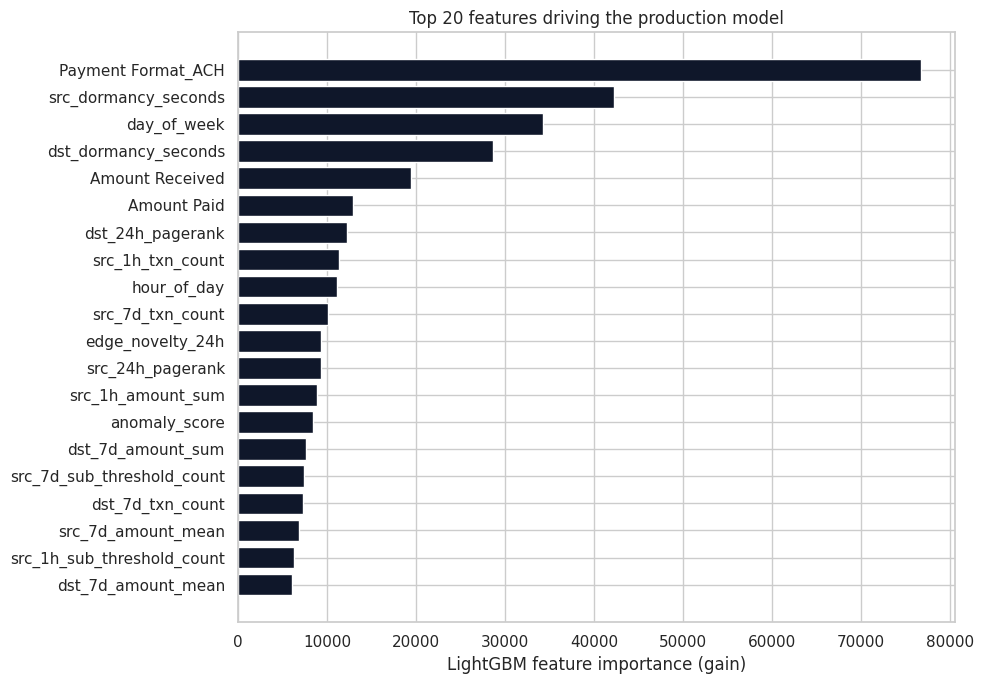

,feature,importance
0,Payment Format_ACH,76683.484914
1,src_dormancy_seconds,42221.585045
2,day_of_week,34266.517405
3,dst_dormancy_seconds,28674.505448
4,Amount Received,19412.362006
5,Amount Paid,12868.960635
6,dst_24h_pagerank,12215.007336
7,src_1h_txn_count,11378.685133
8,hour_of_day,11052.338951
9,src_7d_txn_count,10072.598042


In [8]:
# ---------------------------------------------------------------------
# Extract per-feature importance from the trained LightGBM classifier
# and render the top-20 features as a horizontal bar chart.
#
# Implementation notes:
#   - The supervised classifier is wrapped by CalibratedClassifierCV
#     (isotonic, 3-fold) so the raw LightGBM lives at
#     ``.calibrated_classifiers_[0].estimator``. We extract the base
#     learner rather than the calibrated frontend because the calibrator
#     does not expose importances; they belong to the base learner, not
#     to the probability transform.
#   - We read GAIN importance via ``booster_.feature_importance(
#     importance_type='gain')`` rather than the sklearn
#     ``feature_importances_`` attribute, which on LightGBM defaults to
#     split count. Gain (total loss reduction attributed to a feature)
#     is the decision-relevant measure and matches the view the v0
#     XGBoost run reported. If the booster gain path is unavailable we
#     fall back to split-based importance and relabel the axis so the
#     chart never misrepresents what it shows.
#   - Each CV fold trains its own base estimator; we average importance
#     across the three folds for the canonical production-model view.
#   - Feature names come from the fitted feature pipeline via
#     ``.get_feature_names_out()`` (post-transform names such as
#     ``Payment Format_ACH``, plus the trailing stacked anomaly-score
#     column the AnomalyScoreAppender adds).
# ---------------------------------------------------------------------
from pathlib import Path
import numpy as np
import pandas as pd

from src.models.ensemble import AMLEnsemble

ensemble = AMLEnsemble.load(Path('models/ensemble.pkl'))

calibrated = ensemble.supervised_classifier
fold_estimators = [
    getattr(cc, 'estimator', getattr(cc, 'base_estimator', None))
    for cc in calibrated.calibrated_classifiers_
]

# Prefer gain (decision-relevant). Fall back to split-count only if the
# booster is not reachable, and label the axis to match what is shown.
use_gain = getattr(fold_estimators[0], 'booster_', None) is not None
if use_gain:
    importance_mean = np.vstack([
        est.booster_.feature_importance(importance_type='gain')
        for est in fold_estimators
    ]).mean(axis=0)
    axis_label = 'LightGBM feature importance (gain)'
else:
    importance_mean = np.vstack([
        est.feature_importances_ for est in fold_estimators
    ]).mean(axis=0)
    axis_label = 'LightGBM feature importance (split count)'

feature_names = ensemble.feature_pipeline.get_feature_names_out()

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importance_mean})
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Plot. Reverse the order so the top feature renders at the top of the
# bar chart (matplotlib draws barh bottom-up).
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='#0f172a')
ax.set_xlabel(axis_label)
ax.set_title('Top 20 features driving the production model')
plt.tight_layout()
plt.show()

# Surface the underlying numbers below the chart so a static reader on
# GitHub can quote exact figures rather than estimate bar lengths.
importance_df

## Train-test gap diagnostic (val to test)

The standard overfitting diagnostic is the train-test gap: a large positive value (train >> test) signals memorization, a small gap signals healthy generalization. The production model is refit on train+val combined, so no separate train-fold Precision@k is persisted; the available diagnostic is the val to test gap.

Both folds are now evaluated at the same fixed operational k=384/day (the v1 tuner sweeps at fixed k, replacing the v0 variable-k operating point), so the two Precision@k values are directly comparable and the gap below is meaningful as a generalization check rather than an artifact of mismatched k.

In [9]:
# Val to test gap reporting. The training summary records the
# cost-weighted objective and precision@k on both folds, now both
# measured at the same fixed operational k=384/day, so the two
# precision@k values are directly comparable.
#
# test > val (a positive gap) is expected, not alarming: the held-out
# test window carries ~2x the fraud prevalence of validation, and
# precision@k rises with base rate. The lift figures below make this
# concrete: lift = precision@k / fold base rate inverts the gap, so the
# model's skill over chance is actually higher on validation.
val_block = summary.get('val', {})
val_precision = val_block.get('precision_at_k')
test_precision = float(test['precision_at_k'])
val_objective = val_block.get('objective_cost_per_investigator_hour_usd')
test_objective = float(test['objective_cost_per_investigator_hour_usd'])

# Per-fold base rate = positives / rows; lift = precision@k / base rate
# expresses each precision@k as a multiple of random-alerting at that
# fold's prevalence.
val_positives = int(val_block.get('true_positives', 0)) + int(val_block.get('false_negatives', 0))
test_positives = int(test['true_positives']) + int(test['false_negatives'])
val_rows = int(summary['split']['val_rows'])
test_rows = int(summary['split']['test_rows'])
val_lift = float(val_precision) / (val_positives / val_rows)
test_lift = test_precision / (test_positives / test_rows)

print('Generalization diagnostics')
print('-' * 32)
if val_precision is not None:
    print(f'Validation precision @ k=384:    {float(val_precision):.4f}')
    print(f'Test       precision @ k=384:    {test_precision:.4f}')
    print(f'Gap (test - val):                {test_precision - float(val_precision):+.4f}')
    print()
    print(f'Validation lift over chance:     {val_lift:,.0f}x')
    print(f'Test       lift over chance:     {test_lift:,.0f}x')
    print()
    print(f'Validation objective (cost/hr):  {float(val_objective):,.2f}')
    print(f'Test       objective (cost/hr):  {test_objective:,.2f}')
    print()
    print('Interpretation:')
    print('  - Both precision@k figures are measured at the same fixed')
    print('    k=384/day, so they are directly comparable.')
    print('  - test > val on raw precision@k, but lift = precision@k /')
    print(f'    base rate INVERTS it (val ~{val_lift:,.0f}x vs test ~{test_lift:,.0f}x):')
    print('    the test window has ~2x the fraud prevalence, so the higher')
    print('    test precision@k is a base-rate effect, not greater skill.')
else:
    print('Validation precision@k not present in training summary.')

Generalization diagnostics
--------------------------------
Validation precision @ k=384:    0.7995
Test       precision @ k=384:    0.9115
Gap (test - val):                +0.1120

Validation lift over chance:     801x
Test       lift over chance:     445x

Validation objective (cost/hr):  -80,899.74
Test       objective (cost/hr):  -216,225.90

Interpretation:
  - Both precision@k figures are measured at the same fixed
    k=384/day, so they are directly comparable.
  - test > val on raw precision@k, but lift = precision@k /
    base rate INVERTS it (val ~801x vs test ~445x):
    the test window has ~2x the fraud prevalence, so the higher
    test precision@k is a base-rate effect, not greater skill.
